In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

In [2]:
# path to the processed dataset (notebook is inside the notebooks folder)
# change the file name here if the group saved it with a different name
DATA_PATH = "../results/outputs/warsaw_processed.csv"

df = pd.read_csv(DATA_PATH)
print(df.shape)
df.head()

(9032, 10)


,DATE,SNWD,TAVG,TMAX,TMIN,PRCP_log,Season_Autumn,Season_Spring,Season_Summer,Season_Winter
0,1993-01-01,-1.538307,-2.100851,0.017777,0.024838,-0.515611,False,False,False,True
1,1993-01-02,-1.538307,-2.887727,0.017777,0.024838,-0.515611,False,False,False,True
2,1993-01-06,-1.538307,-1.385510,0.017777,-3.213549,-0.515611,False,False,False,True
3,1993-01-08,-0.106787,-0.968228,0.017777,0.024838,-0.515611,False,False,False,True
4,1993-01-09,-0.106787,-1.003995,0.017777,0.024838,-0.515611,False,False,False,True


In [3]:
# check missing values and basic statistics
print(df.isna().sum())
df.describe()

DATE             0
SNWD             0
TAVG             0
TMAX             0
TMIN             0
PRCP_log         0
Season_Autumn    0
Season_Spring    0
Season_Summer    0
Season_Winter    0
dtype: int64


,SNWD,TAVG,TMAX,TMIN,PRCP_log
count,9.032000e+03,9.032000e+03,9.032000e+03,9.032000e+03,9.032000e+03
mean,-7.866948e-17,-1.510454e-16,-1.101373e-17,1.408184e-16,5.664202e-17
std,1.000055e+00,1.000055e+00,1.000055e+00,1.000055e+00,1.000055e+00
min,-1.538307e+00,-3.376543e+00,-2.360363e+00,-4.687197e+00,-5.156106e-01
25%,-1.067865e-01,-8.251596e-01,-4.927844e-01,-1.934799e-01,-5.156106e-01
50%,-1.067865e-01,9.405089e-03,1.777657e-02,2.483837e-02,-5.156106e-01
75%,-1.067865e-01,8.439698e-01,5.955166e-01,2.249634e-01,2.631055e-01
max,1.665248e+01,2.358109e+00,2.342172e+00,3.063101e+00,3.202680e+00


In [4]:
# tests each feature alone and ranks them by mean 5-fold CV R2
def test_single_features(X_train, y_train):
    results = []
    for col in X_train.columns:
        score = cross_val_score(LinearRegression(), X_train[[col]], y_train,
                                cv=5, scoring="r2").mean()
        results.append((col, score))
    table = pd.DataFrame(results, columns=["Feature", "CV_R2"])
    table = table.sort_values("CV_R2", ascending=False).reset_index(drop=True)
    return table

In [5]:
season_cols = [col for col in df.columns if col.startswith("Season_")]

y_a = df["TAVG"]
X_a = df[["SNWD", "TMIN", "PRCP_log"] + season_cols]   # TMAX and DATE left out

Xa_train, Xa_test, ya_train, ya_test = train_test_split(
    X_a, y_a, test_size=0.2, random_state=42)

In [6]:
res_a = test_single_features(Xa_train, ya_train)
res_a

,Feature,CV_R2
0,TMIN,0.505046
1,Season_Summer,0.434336
2,Season_Winter,0.382735
3,SNWD,0.026914
4,PRCP_log,0.013542
5,Season_Autumn,-0.000822
6,Season_Spring,-0.001112


In [7]:
best_a = res_a.loc[0, "Feature"]
print("Best single feature for TAVG:", best_a)

model_a = LinearRegression()
model_a.fit(Xa_train[[best_a]], ya_train)
pred_a = model_a.predict(Xa_test[[best_a]])

r2_a = r2_score(ya_test, pred_a)
rmse_a = np.sqrt(mean_squared_error(ya_test, pred_a))

print("Intercept:", round(model_a.intercept_, 4), "| Slope:", round(model_a.coef_[0], 4))
print("R2   :", round(r2_a, 4))
print("RMSE :", round(rmse_a, 4))

Best single feature for TAVG:

 TMIN
Intercept: -0.0018 | Slope: 0.7083
R2   : 0.4942
RMSE : 0.7008


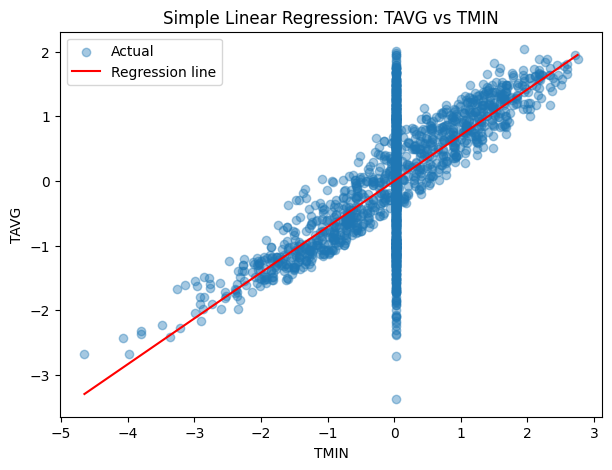

In [8]:
order = np.argsort(Xa_test[best_a].values)
plt.figure(figsize=(7, 5))
plt.scatter(Xa_test[best_a], ya_test, alpha=0.4, label="Actual")
plt.plot(Xa_test[best_a].values[order], pred_a[order], color="red", label="Regression line")
plt.xlabel(best_a)
plt.ylabel("TAVG")
plt.title("Simple Linear Regression: TAVG vs " + best_a)
plt.legend()
plt.show()

In [9]:
y_b = df["PRCP_log"]
X_b = df[["SNWD", "TAVG", "TMAX", "TMIN"] + season_cols]

Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    X_b, y_b, test_size=0.2, random_state=42)

In [10]:
res_b = test_single_features(Xb_train, yb_train)
res_b

,Feature,CV_R2
0,TMAX,0.022942
1,TAVG,0.013911
2,Season_Winter,0.012185
3,Season_Summer,0.004389
4,SNWD,0.002412
5,TMIN,0.000745
6,Season_Autumn,-0.000340
7,Season_Spring,-0.000561


In [11]:
best_b = res_b.loc[0, "Feature"]
print("Best single feature for PRCP_log:", best_b)

model_b = LinearRegression()
model_b.fit(Xb_train[[best_b]], yb_train)
pred_b = model_b.predict(Xb_test[[best_b]])

r2_b = r2_score(yb_test, pred_b)
rmse_b = np.sqrt(mean_squared_error(yb_test, pred_b))

print("Intercept:", round(model_b.intercept_, 4), "| Slope:", round(model_b.coef_[0], 4))
print("R2   :", round(r2_b, 4))
print("RMSE :", round(rmse_b, 4))

Best single feature for PRCP_log: TMAX
Intercept: 0.007 | Slope: -0.1542
R2   : 0.0143
RMSE : 0.9736


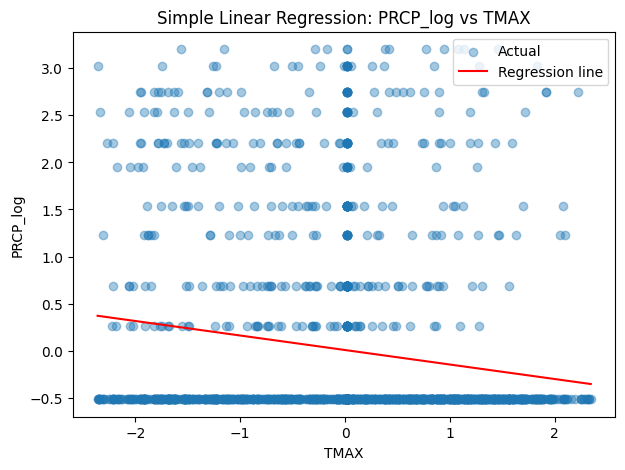

In [12]:
order = np.argsort(Xb_test[best_b].values)
plt.figure(figsize=(7, 5))
plt.scatter(Xb_test[best_b], yb_test, alpha=0.4, label="Actual")
plt.plot(Xb_test[best_b].values[order], pred_b[order], color="red", label="Regression line")
plt.xlabel(best_b)
plt.ylabel("PRCP_log")
plt.title("Simple Linear Regression: PRCP_log vs " + best_b)
plt.legend()
plt.show()

In [13]:
summary = pd.DataFrame({
    "Task": ["Temperature (TAVG)", "Rainfall (PRCP_log)"],
    "Model": ["Simple Linear Regression"] * 2,
    "Feature used": [best_a, best_b],
    "R2": [round(r2_a, 4), round(r2_b, 4)],
    "RMSE": [round(rmse_a, 4), round(rmse_b, 4)],
})
summary

,Task,Model,Feature used,R2,RMSE
0,Temperature (TAVG),Simple Linear Regression,TMIN,0.4942,0.7008
1,Rainfall (PRCP_log),Simple Linear Regression,TMAX,0.0143,0.9736
